In this notebook, we would like to test the differences among greedy, unique greedy assignment and hungarian algorithm with cost function called cosine similairty which is one of the quality metric of real data and synthetic data  

# 1. Data loading and preparation

In [1]:
import warnings, numpy as np, pandas as pd
warnings.filterwarnings('ignore')

data = pd.read_csv('C:/Users/Gopi.Battineni/OneDrive - University of Limerick/Desktop/FORGE/Synthetic-data_Audit/Datasets/Cancer.csv')

# droping diagnosis column which is not the main focus here

data.drop(['diagnosis', 'id', 'Unnamed: 32'], axis = 1, inplace = True)
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   radius_mean              569 non-null    float64
 1   texture_mean             569 non-null    float64
 2   perimeter_mean           569 non-null    float64
 3   area_mean                569 non-null    float64
 4   smoothness_mean          569 non-null    float64
 5   compactness_mean         569 non-null    float64
 6   concavity_mean           569 non-null    float64
 7   concave points_mean      569 non-null    float64
 8   symmetry_mean            569 non-null    float64
 9   fractal_dimension_mean   569 non-null    float64
 10  radius_se                569 non-null    float64
 11  texture_se               569 non-null    float64
 12  perimeter_se             569 non-null    float64
 13  area_se                  569 non-null    float64
 14  smoothness_se            5

In [2]:
import sdv
from sdv.metadata import SingleTableMetadata
metadata = SingleTableMetadata()
metadata.detect_from_dataframe(data)
print(f"Data shape: {data.shape}")
print(f"Columns: {list(data.columns)}")

Data shape: (569, 30)
Columns: ['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst']


In [3]:
from sdv.single_table import (
    GaussianCopulaSynthesizer,
    CTGANSynthesizer,
    CopulaGANSynthesizer,
    TVAESynthesizer,
)

# 1) Define the four models
models = {
    "GaussianCopula": GaussianCopulaSynthesizer(metadata=metadata),
    "CTGAN": CTGANSynthesizer(metadata=metadata),
    "CopulaGAN": CopulaGANSynthesizer(metadata=metadata),
    "TVAE": TVAESynthesizer(metadata=metadata),
}

# 2) Fit all models on the same real data
for name, model in models.items():
    print(f"Fitting {name}...")
    model.fit(data)

print("All models fitted!")

Fitting GaussianCopula...
Fitting CTGAN...
Fitting CopulaGAN...
Fitting TVAE...
All models fitted!


In [4]:
from numpy.linalg import norm
synthetic_data = {}
n_rows = len(data)  

for name, model in models.items():
    synthetic_data[name] = model.sample(num_rows=n_rows)
    
def normalize_rows(X):
    return X / (norm(X, axis=1, keepdims=True) + 1e-12)

real_matrix = normalize_rows(data.to_numpy(float))

cosine_results = {}

Lets compute cosine similarity matrix

In [5]:
cosine_dfs = {}  # store results for all models

for model_name, synth_df in synthetic_data.items():

    print(f"Building cosine similarity DataFrame for {model_name}...")

    # Normalize synthetic matrix
    synth_matrix = normalize_rows(synth_df.to_numpy(float))

    # Compute cosine similarity matrix
    cosine_matrix = real_matrix @ synth_matrix.T

    # Build DataFrame (first 10x10 block for readability)
    cosine_df = pd.DataFrame(
        cosine_matrix[:569, :569],  # top-left 10×10 portion
        index=[f"R{i+1}" for i in range(569)],
        columns=[f"S{j+1}" for j in range(569)]
    )

    # Save in dictionary
    cosine_dfs[model_name] = cosine_df

    print(cosine_df, "\n")


Building cosine similarity DataFrame for GaussianCopula...
            S1        S2        S3        S4        S5        S6        S7  \
R1    0.986684  0.958735  0.968298  0.961272  0.977315  0.996924  0.997187   
R2    0.999509  0.985613  0.992620  0.988357  0.996488  0.996266  0.997469   
R3    0.999736  0.988373  0.994888  0.991016  0.997787  0.994884  0.995913   
R4    0.996525  0.991146  0.990757  0.990799  0.995809  0.994881  0.991600   
R5    0.997247  0.994357  0.999548  0.997016  0.999043  0.985012  0.986424   
...        ...       ...       ...       ...       ...       ...       ...   
R565  0.999017  0.988583  0.996121  0.991735  0.997720  0.992322  0.994013   
R566  0.999656  0.990084  0.996311  0.992765  0.998529  0.993240  0.994311   
R567  0.999294  0.994325  0.997934  0.996147  0.999796  0.991111  0.991101   
R568  0.999841  0.988631  0.994296  0.990888  0.997785  0.995837  0.996297   
R569  0.986792  0.986289  0.981341  0.984262  0.987482  0.986737  0.980364   

    

# 2. Greedy assignment

In [6]:
import numpy as np
import pandas as pd
from numpy.linalg import norm
from sdv.single_table import (
    GaussianCopulaSynthesizer,
    CTGANSynthesizer,
    CopulaGANSynthesizer,
    TVAESynthesizer,
)

# -------------------------------------------------
# Helper: row normalization for cosine similarity
# -------------------------------------------------
def normalize_rows(X):
    return X / (norm(X, axis=1, keepdims=True) + 1e-12)

# -------------------------------------------------
# Cosine similarity & association
# -------------------------------------------------
def associate_real_with_synthetic(real_data: pd.DataFrame, synthetic_data: pd.DataFrame):

    # Use ALL numeric columns from Wisconsin dataset
    num_cols = real_data.select_dtypes(include=["number"]).columns.tolist()

    # Build matrices
    R = real_data[num_cols].to_numpy(dtype=float)
    S = synthetic_data[num_cols].to_numpy(dtype=float)

    # Normalize rows
    R_norm = normalize_rows(R)
    S_norm = normalize_rows(S)

    # Cosine similarity matrix (N_real x N_synth)
    cos_sim = R_norm @ S_norm.T

    # Best match per real row
    best_s_idx = np.argmax(cos_sim, axis=1)
    best_sim   = cos_sim[np.arange(len(R)), best_s_idx]

    return best_s_idx, best_sim, cos_sim

# -------------------------------------------------
# 1) Define and fit the FOUR models
#    (assumes `metadata` and `data` are already defined)
# -------------------------------------------------
model_classes = {
    "GaussianCopula": GaussianCopulaSynthesizer,
    "CTGAN":          CTGANSynthesizer,
    "CopulaGAN":      CopulaGANSynthesizer,
    "TVAE":           TVAESynthesizer,
}

models = {}
synthetic_data = {}

for name, cls in model_classes.items():
    print(f"Fitting {name}...")
    model = cls(metadata=metadata)
    model.fit(data)
    models[name] = model

    # Sample synthetic data with same number of rows as real data
    synthetic_data[name] = model.sample(num_rows=len(data))

# -------------------------------------------------
# 2) Run association for FOUR MODELS
# -------------------------------------------------
results = {}

for name, synth_df in synthetic_data.items():

    print(f"\n==============================")
    print(f"{name}: Real → Synthetic Associations")
    print(f"==============================\n")

    best_indices, best_sims, cos_matrix = associate_real_with_synthetic(data, synth_df)

    # Store results in case you need them later
    results[name] = {
        "best_indices": best_indices,
        "best_sims": best_sims,
        "cos_matrix": cos_matrix,
    }

    # Display associations
    for i in range(len(data)):
        r_name = f"R{i+1}"
        s_name = f"S{best_indices[i] + 1}"
        sim_val = best_sims[i]
        print(f"{r_name} → {s_name}   cosine similarity = {sim_val:.4f}")

Fitting GaussianCopula...
Fitting CTGAN...
Fitting CopulaGAN...
Fitting TVAE...

GaussianCopula: Real → Synthetic Associations

R1 → S371   cosine similarity = 0.9982
R2 → S98   cosine similarity = 0.9999
R3 → S396   cosine similarity = 1.0000
R4 → S517   cosine similarity = 0.9997
R5 → S280   cosine similarity = 0.9999
R6 → S61   cosine similarity = 0.9999
R7 → S305   cosine similarity = 1.0000
R8 → S162   cosine similarity = 1.0000
R9 → S43   cosine similarity = 0.9999
R10 → S542   cosine similarity = 0.9999
R11 → S44   cosine similarity = 1.0000
R12 → S128   cosine similarity = 1.0000
R13 → S141   cosine similarity = 0.9999
R14 → S244   cosine similarity = 1.0000
R15 → S502   cosine similarity = 1.0000
R16 → S43   cosine similarity = 0.9999
R17 → S128   cosine similarity = 1.0000
R18 → S128   cosine similarity = 1.0000
R19 → S371   cosine similarity = 0.9997
R20 → S90   cosine similarity = 1.0000
R21 → S387   cosine similarity = 1.0000
R22 → S567   cosine similarity = 0.9999
R23 → S

# 4. Hungarian algorithm

                num_cols=None):
    """
    Perform optimal 1-to-1 matching between real and synthetic samples
    using the Hungarian algorithm on (1 - cosine_similarity) as cost.

    Returns
    -------
    row_ind : np.ndarray
        Indices of real samples in the matching (0-based).
    col_ind : np.ndarray
        Indices of synthetic samples matched to each real (0-based).
    selected_similarities : np.ndarray
        Cosine similarity values for each matched pair.
    avg_similarity : float
        Average cosine similarity over the matched pairs.
    cos_sim : np.ndarray
        Full cosine similarity matrix (N_real x N_synth).
    """

In [8]:
import numpy as np
import pandas as pd
from numpy.linalg import norm
from scipy.optimize import linear_sum_assignment
from sdv.single_table import (
    GaussianCopulaSynthesizer,
    CTGANSynthesizer,
    CopulaGANSynthesizer,
    TVAESynthesizer,
)

# ---------- cosine similarity (reuse your earlier function) ----------

def normalize_rows(X: np.ndarray) -> np.ndarray:
    norms = norm(X, axis=1, keepdims=True) + 1e-12
    return X / norms

def cosine_similarity_matrix(real_df: pd.DataFrame,
                             synth_df: pd.DataFrame,
                             num_cols=None) -> np.ndarray:
    if num_cols is None:
        num_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()

    R = real_df[num_cols].to_numpy(dtype=float)
    S = synth_df[num_cols].to_numpy(dtype=float)

    R_norm = normalize_rows(R)
    S_norm = normalize_rows(S)

    return R_norm @ S_norm.T


# ---------- Hungarian-based optimal matching ----------

def hungarian_match(real_df: pd.DataFrame,
                    synth_df: pd.DataFrame,
                    num_cols=None):

    # NOTE: call cosine_similarity_matrix (not cosine_matrix)
    cos_sim = cosine_similarity_matrix(real_df, synth_df, num_cols)
    n_real, n_synth = cos_sim.shape

    # We want to maximize similarity → minimize cost = 1 - similarity
    if n_real <= n_synth:
        cost_matrix = 1.0 - cos_sim
        row_ind, col_ind = linear_sum_assignment(cost_matrix)
        selected_similarities = cos_sim[row_ind, col_ind]
    else:
        cost_matrix = 1.0 - cos_sim.T
        col_ind, row_ind = linear_sum_assignment(cost_matrix)
        selected_similarities = cos_sim[row_ind, col_ind]

    avg_similarity = float(selected_similarities.mean())
    return row_ind, col_ind, selected_similarities, avg_similarity, cos_sim


# ---------- 1. Fit the four models ----------

real_df = data  # your real Wisconsin dataset

model_classes = {
    "GaussianCopula": GaussianCopulaSynthesizer,
    "CTGAN":          CTGANSynthesizer,
    "CopulaGAN":      CopulaGANSynthesizer,
    "TVAE":           TVAESynthesizer,
}

models = {}
synthetic_tables = {}

for name, cls in model_classes.items():
    print(f"Fitting {name}...")
    model = cls(metadata=metadata)
    model.fit(real_df)
    models[name] = model
    synthetic_tables[name] = model.sample(num_rows=len(real_df))


# ---------- 2. Run Hungarian matching for each model ----------

results = {}

for name, synth_df in synthetic_tables.items():
    print(f"\n==============================")
    print(f"{name}: Hungarian matching (cosine, all numeric features)")
    print(f"==============================")

    row_ind, col_ind, sims, avg_sim, cos_matrix = hungarian_match(
        real_df, synth_df, num_cols=None
    )

    results[name] = {
        "row_ind": row_ind,
        "col_ind": col_ind,
        "similarities": sims,
        "avg_similarity": avg_sim,
        "cos_matrix": cos_matrix,
    }

    print(f"Average cosine similarity (Hungarian match): {avg_sim:.4f}\n")

    # show first 10 matched pairs
    for k in range(min(10, len(row_ind))):
        r_idx = row_ind[k]
        s_idx = col_ind[k]
        sim_val = sims[k]
        print(f"R{r_idx+1} ↔ S{s_idx+1}   cosine similarity = {sim_val:.4f}")


Fitting GaussianCopula...
Fitting CTGAN...
Fitting CopulaGAN...
Fitting TVAE...

GaussianCopula: Hungarian matching (cosine, all numeric features)
Average cosine similarity (Hungarian match): 0.9996

R1 ↔ S556   cosine similarity = 0.9976
R2 ↔ S94   cosine similarity = 0.9998
R3 ↔ S513   cosine similarity = 0.9999
R4 ↔ S525   cosine similarity = 0.9990
R5 ↔ S210   cosine similarity = 0.9994
R6 ↔ S61   cosine similarity = 0.9999
R7 ↔ S302   cosine similarity = 0.9999
R8 ↔ S117   cosine similarity = 0.9995
R9 ↔ S430   cosine similarity = 0.9998
R10 ↔ S170   cosine similarity = 0.9995

CTGAN: Hungarian matching (cosine, all numeric features)
Average cosine similarity (Hungarian match): 0.9220

R1 ↔ S359   cosine similarity = 0.9314
R2 ↔ S452   cosine similarity = 0.9512
R3 ↔ S344   cosine similarity = 0.9793
R4 ↔ S491   cosine similarity = 0.9117
R5 ↔ S137   cosine similarity = 0.8921
R6 ↔ S546   cosine similarity = 0.9471
R7 ↔ S226   cosine similarity = 0.9493
R8 ↔ S306   cosine similari

In [9]:
with pd.ExcelWriter("hungarian_mappings_all_models.xlsx") as writer:
    for name, synth_df in synthetic_tables.items():
        row_ind   = results[name]["row_ind"]
        col_ind   = results[name]["col_ind"]
        sims      = results[name]["similarities"]

        mapping_df = pd.DataFrame({
            "real_index": row_ind,
            "synthetic_index": col_ind,
            "real_label": [f"R{i+1}" for i in row_ind],
            "synthetic_label": [f"S{j+1}" for j in col_ind],
            "cosine_similarity": sims
        })

        mapping_df.to_excel(writer, sheet_name=name, index=False)

In [10]:
feature_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()
# This should be your 30 features
print(len(feature_cols), "features")  # should print 30


30 features


In [11]:
# ---------- Create two Excel files: real (30 features) and matched synthetic (30 features) ----------

chosen_model = "GaussianCopula"  # change if you want CTGAN / CopulaGAN / TVAE

row_ind = results[chosen_model]["row_ind"]
col_ind = results[chosen_model]["col_ind"]

# 30-feature real samples (only the rows involved, in the Hungarian order)
real_30 = real_df.iloc[row_ind][feature_cols].copy()

# 30-feature synthetic samples matched to them
synth_30 = synthetic_tables[chosen_model].iloc[col_ind][feature_cols].copy()

# Save to Excel
real_filename = f"{chosen_model}_real_30_features.xlsx"
synth_filename = f"{chosen_model}_synthetic_30_features.xlsx"

real_30.to_excel(real_filename, index=False)
synth_30.to_excel(synth_filename, index=False)

print(f"Saved real samples (30 features) to: {real_filename}")
print(f"Saved synthetic samples (30 features) to: {synth_filename}")

Saved real samples (30 features) to: GaussianCopula_real_30_features.xlsx
Saved synthetic samples (30 features) to: GaussianCopula_synthetic_30_features.xlsx


## 4.1. Scenario 1

This is the condition where we consider the scenario where |R| = |S|. It is possible that the number of synthetic samples is significantly larger than the real ones, i.e., |R| > |S|.

Lets imagine

Number of real samples = N
Number of synthetic samples = 3N

In such a case, we will:

- Use the Hungarian algorithm to select the best N synthetic samples (Option 1).
- For the remaining 4N synthetic samples, compute their closeness to the real data (Option 2).
- Optionally, filter out synthetic samples that are "too close" to any real sample (for privacy).

In [29]:
gc_model   = GaussianCopulaSynthesizer(metadata=metadata)
ctgan_model = CTGANSynthesizer(metadata=metadata)
cop_model   = CopulaGANSynthesizer(metadata=metadata)
tvae_model  = TVAESynthesizer(metadata=metadata)

# Fit models
gc_model.fit(data)
ctgan_model.fit(data)
cop_model.fit(data)
tvae_model.fit(data)

# Sample 1500 rows from each model
synthetic_data_gaussian_copula = gc_model.sample(num_rows=1500)
synthetic_data_ctgan           = ctgan_model.sample(num_rows=1500)
synthetic_data_copulagan       = cop_model.sample(num_rows=1500)
synthetic_data_tvae            = tvae_model.sample(num_rows=1500)

# Show structure
print("\nGaussianCopula synthetic data:")
synthetic_data_gaussian_copula.info()

print("\nCTGAN synthetic data:")
synthetic_data_ctgan.info()

print("\nCopulaGAN synthetic data:")
synthetic_data_copulagan.info()

print("\nTVAE synthetic data:")
synthetic_data_tvae.info()


GaussianCopula synthetic data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   radius_mean              1500 non-null   float64
 1   texture_mean             1500 non-null   float64
 2   perimeter_mean           1500 non-null   float64
 3   area_mean                1500 non-null   float64
 4   smoothness_mean          1500 non-null   float64
 5   compactness_mean         1500 non-null   float64
 6   concavity_mean           1500 non-null   float64
 7   concave points_mean      1500 non-null   float64
 8   symmetry_mean            1500 non-null   float64
 9   fractal_dimension_mean   1500 non-null   float64
 10  radius_se                1500 non-null   float64
 11  texture_se               1500 non-null   float64
 12  perimeter_se             1500 non-null   float64
 13  area_se                  1500 non-null   float

In [30]:
import numpy as np
import pandas as pd
from numpy.linalg import norm
from scipy.optimize import linear_sum_assignment

# ------- cosine similarity helpers (full numeric features) -------

def normalize_rows(X: np.ndarray) -> np.ndarray:
    norms = norm(X, axis=1, keepdims=True) + 1e-12
    return X / norms

def cosine_similarity_matrix(real_df: pd.DataFrame,
                             synth_df: pd.DataFrame,
                             num_cols=None) -> np.ndarray:
    """
    Compute cosine similarity matrix between real and synthetic samples.
    If num_cols is None, use all numeric columns from real_df.
    """
    if num_cols is None:
        num_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()

    R = real_df[num_cols].to_numpy(dtype=float)
    S = synth_df[num_cols].to_numpy(dtype=float)

    R_norm = normalize_rows(R)
    S_norm = normalize_rows(S)

    return R_norm @ S_norm.T


# ------- Hungarian-based optimal matching for |S| >= |R| -------

def hungarian_match_subset(real_df: pd.DataFrame,
                           synth_df: pd.DataFrame,
                           num_cols=None,
                           privacy_threshold: float = 0.95):
    """
    Case: |S| >= |R| (e.g., synthetic is larger than real).

    1. Use Hungarian algorithm to pick the best |R| synthetic samples.
    2. For remaining synthetic samples, compute their max similarity to real.
    3. Identify those above privacy_threshold as too-close.
    """

    # use all numeric features if num_cols is None
    cos_sim = cosine_similarity_matrix(real_df, synth_df, num_cols)
    n_real, n_synth = cos_sim.shape

    if n_synth < n_real:
        raise ValueError("This function assumes |S| >= |R|.")

    # 1. Hungarian on full cost matrix (N_real x N_synth)
    cost_matrix = 1.0 - cos_sim
    row_ind, col_ind = linear_sum_assignment(cost_matrix)

    selected_similarities = cos_sim[row_ind, col_ind]
    avg_similarity = float(selected_similarities.mean())

    # 2. Remaining synthetic samples
    all_synth_indices = set(range(n_synth))
    matched_synth_indices = set(col_ind.tolist())
    remaining_synth_indices = sorted(list(all_synth_indices - matched_synth_indices))

    # For remaining synthetics, compute max similarity to any real
    max_sim_remaining = {}
    for j in remaining_synth_indices:
        max_sim = float(cos_sim[:, j].max())
        max_sim_remaining[j] = max_sim

    # 3. Identify too-close synthetic samples for privacy
    too_close = {j: s for j, s in max_sim_remaining.items()
                 if s >= privacy_threshold}

    return {
        "row_ind": row_ind,
        "col_ind": col_ind,
        "selected_similarities": selected_similarities,
        "avg_similarity": avg_similarity,
        "cos_sim": cos_sim,
        "remaining_synth_indices": remaining_synth_indices,
        "max_sim_remaining": max_sim_remaining,
        "too_close": too_close
    }


# ------- Use it on your data (full features, Gaussian Copula example) -------

real_df = data                     # real Wisconsin dataset
synth_df = synthetic_data_gaussian_copula  # e.g. 1500 samples from GC model

result = hungarian_match_subset(real_df, synth_df,
                                num_cols=None,          # use ALL numeric features
                                privacy_threshold=0.95)

row_ind = result["row_ind"]
col_ind = result["col_ind"]
sims    = result["selected_similarities"]
avg_sim = result["avg_similarity"]

print("Optimal Real → Synthetic assignments (Hungarian, |S| >= |R|):\n")
for r_idx, s_idx, sim in zip(row_ind, col_ind, sims):
    r_name = f"R{r_idx + 1}"
    s_name = f"S{s_idx + 1}"
    print(f"{r_name}  →  {s_name}   cosine similarity = {sim:.4f}")

print(f"\nAverage cosine similarity over matched pairs: {avg_sim:.4f}")

print("\nPrivacy check on remaining synthetic samples:")
print(f"Total synthetic samples: {synth_df.shape[0]}")
print(f"Matched synthetic samples: {len(col_ind)}")
print(f"Remaining synthetic samples: {len(result['remaining_synth_indices'])}")

too_close = result["too_close"]
print("\nNumber of remaining synthetic samples too close to real "
      f"(cosine >= 0.95): {len(too_close)}")

# print at most 10 too-close synthetic samples (sorted by similarity, descending)
if too_close:
    print("\nUp to 10 'too close' remaining synthetic samples:")
    too_close_sorted = sorted(too_close.items(), key=lambda x: x[1], reverse=True)
    for j, sim in too_close_sorted[:10]:
        print(f"S{j+1} is too close to some real sample (max cosine = {sim:.4f})")

Optimal Real → Synthetic assignments (Hungarian, |S| >= |R|):

R1  →  S1298   cosine similarity = 0.9994
R2  →  S627   cosine similarity = 1.0000
R3  →  S1408   cosine similarity = 1.0000
R4  →  S976   cosine similarity = 0.9999
R5  →  S1039   cosine similarity = 0.9999
R6  →  S61   cosine similarity = 0.9999
R7  →  S1393   cosine similarity = 1.0000
R8  →  S162   cosine similarity = 1.0000
R9  →  S913   cosine similarity = 1.0000
R10  →  S542   cosine similarity = 0.9999
R11  →  S628   cosine similarity = 1.0000
R12  →  S128   cosine similarity = 1.0000
R13  →  S141   cosine similarity = 0.9999
R14  →  S956   cosine similarity = 1.0000
R15  →  S1009   cosine similarity = 0.9999
R16  →  S777   cosine similarity = 0.9999
R17  →  S1398   cosine similarity = 1.0000
R18  →  S68   cosine similarity = 1.0000
R19  →  S371   cosine similarity = 0.9997
R20  →  S127   cosine similarity = 1.0000
R21  →  S1023   cosine similarity = 1.0000
R22  →  S1279   cosine similarity = 0.9999
R23  →  S1025   

## 4.2. Scenario 2

what if we generate 500 synthetic samples (500*S) for 10 real samples |S| >> |R|

 """
    Case: |S| >> |R|

    1. Cluster synthetic samples into K clusters (K = |R| by default).
    2. Use cluster centroids as representative synthetic points.
    3. Match each real sample to the nearest centroid using cosine similarity.

    Returns
    -------
    centroid_assignments : np.ndarray
        For each real sample i, the index (0..K-1) of the centroid it is closest to.
    centroid_similarities : np.ndarray
        Cosine similarity between each real sample and its assigned centroid.
    centroids : np.ndarray
        The centroid vectors in original feature space (shape: K x d).
    cos_sim_matrix : np.ndarray
        Cosine similarity matrix between real samples and centroids (N_real x K).
    kmeans_labels : np.ndarray
        Cluster label for each synthetic sample (length |S|).
    """

In [31]:
# lets create synthetic data with 5000 samples

synthetic_data_gaussian_copula = gc_model.sample(num_rows=5000)
synthetic_data_ctgan           = ctgan_model.sample(num_rows=5000)
synthetic_data_copulagan       = cop_model.sample(num_rows=5000)
synthetic_data_tvae            = tvae_model.sample(num_rows=5000)

In [32]:
# Cluster synthetic data and match real to centroids

from sklearn.cluster import KMeans

def cluster_synthetic_and_match(real_df: pd.DataFrame,
                                synth_df: pd.DataFrame,
                                num_cols,
                                n_clusters: int = None,
                                random_state: int = 0):

    # Extract numeric data
    R = real_df[num_cols].to_numpy(dtype=float)
    S = synth_df[num_cols].to_numpy(dtype=float)

    n_real = R.shape[0]


    if n_clusters is None:
        n_clusters = n_real

    # Normalize synthetic data for clustering (cosine ~ Euclidean on unit sphere)
    S_norm = normalize_rows(S)

    # ---------- KMeans clustering on synthetic samples ----------
    kmeans = KMeans(n_clusters=n_clusters,
                    random_state=random_state,
                    n_init=10)
    kmeans.fit(S_norm)

    # Centroids are in normalized space; we can treat them as direction vectors
    centroids = kmeans.cluster_centers_        # shape: (K, d)
    centroids_norm = normalize_rows(centroids) # just to be safe

    # Normalize real data for cosine similarity
    R_norm = normalize_rows(R)

    # ---------- Cosine similarity: real vs centroids ----------
    # cos_sim[i, k] = cosine similarity between real i and centroid k
    cos_sim_matrix = R_norm @ centroids_norm.T   # shape: (N_real, K)

    # For each real sample, find the closest centroid (max cosine similarity)
    centroid_assignments = np.argmax(cos_sim_matrix, axis=1)
    centroid_similarities = cos_sim_matrix[np.arange(n_real), centroid_assignments]

    return (centroid_assignments,
            centroid_similarities,
            centroids,
            cos_sim_matrix,
            kmeans.labels_)

In [33]:
real_df = data

# Use ALL numeric features from the dataset
num_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()
print(f"Using {len(num_cols)} numeric features:\n{num_cols}")

# Dict of synthetic DATAFRAMES (make sure these exist already and have same columns)
synthetic_tables = {
    "GaussianCopula": synthetic_data_gaussian_copula,
    "CTGAN":          synthetic_data_ctgan,
    "CopulaGAN":      synthetic_data_copulagan,
    "TVAE":           synthetic_data_tvae,
}

cluster_results = {}

for model_name, synth_df in synthetic_tables.items():
    print("\n===================================================")
    print(f"{model_name}: clustering synthetic and matching to real (all numeric features)")
    print("===================================================\n")

    (centroid_assignments,
     centroid_sims,
     centroids,
     cos_sim_centroids,
     synth_cluster_labels) = cluster_synthetic_and_match(
        real_df,
        synth_df,
        num_cols=num_cols,          # <-- all numeric features here
        n_clusters=len(real_df),    # usually use |R|
        random_state=42
    )

    # Store results
    cluster_results[model_name] = {
        "centroid_assignments": centroid_assignments,
        "centroid_sims": centroid_sims,
        "centroids": centroids,
        "cos_sim_centroids": cos_sim_centroids,
        "synth_cluster_labels": synth_cluster_labels,
    }

    print("Real → Centroid assignments (|S| >> |R|, clustered):\n")
    for i, (c_idx, sim) in enumerate(zip(centroid_assignments, centroid_sims)):
        r_name = f"R{i+1}"
        print(f"{r_name}  →  Centroid {c_idx}   cosine similarity = {sim:.4f}")

    avg_centroid_sim = float(centroid_sims.mean())
    print(f"\nAverage cosine similarity (real vs assigned centroid): {avg_centroid_sim:.4f}")

    print("\nNumber of synthetic samples per cluster (approx per real):")
    cluster_counts = np.bincount(synth_cluster_labels)
    for k, count in enumerate(cluster_counts):
        print(f"Cluster {k}: {count} synthetic samples")


Using 30 numeric features:
['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst']

GaussianCopula: clustering synthetic and matching to real (all numeric features)

Real → Centroid assignments (|S| >> |R|, clustered):

R1  →  Centroid 280   cosine similarity = 0.9997
R2  →  Centroid 154   cosine similarity = 1.0000
R3  →  Centroid 1   cosine similarity = 1.0000
R4  →  Centroid 467   cosine similarity = 1.0000
R5  →  Centroid 281   cosine similarity = 0.9999
R6  →  Centroid 33   cosine similarity = 0.9999

# 5. Graphical visulization

Using 30 numeric features:
['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst']

=== PCA + clustering for GaussianCopula ===


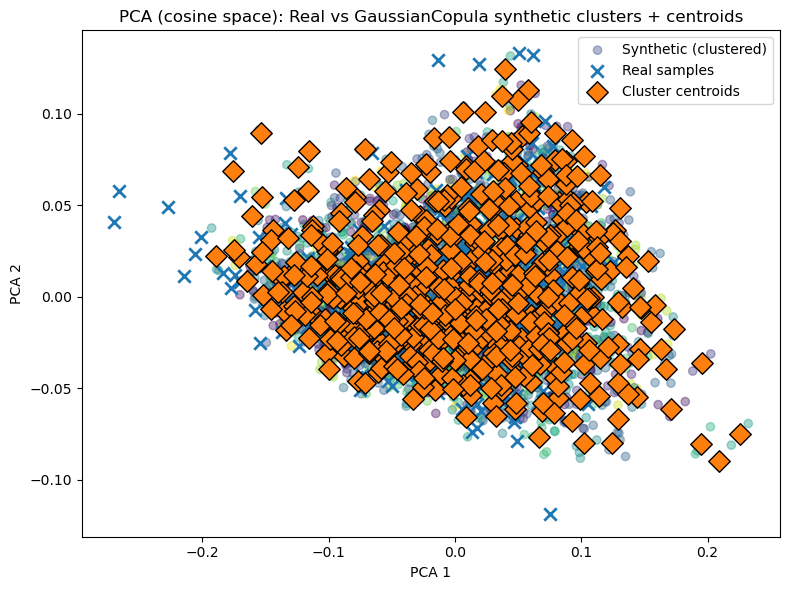


=== PCA + clustering for CTGAN ===


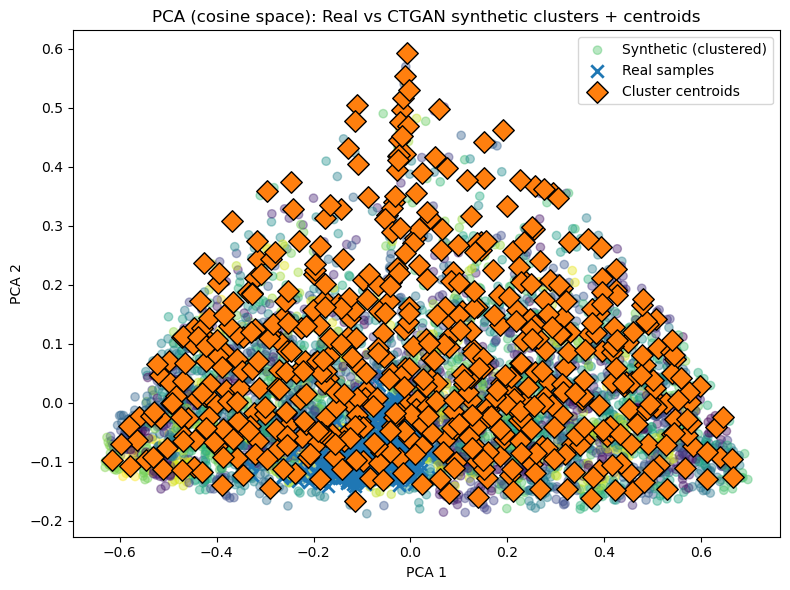


=== PCA + clustering for CopulaGAN ===


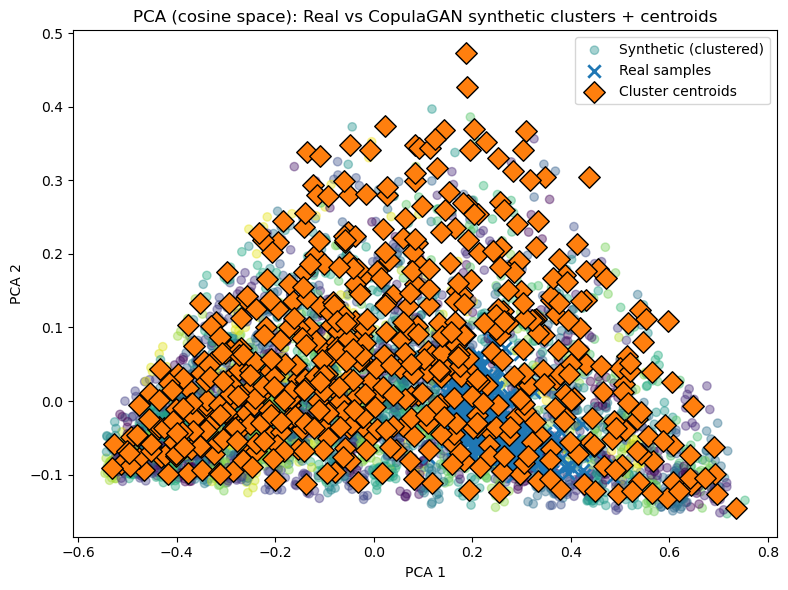


=== PCA + clustering for TVAE ===


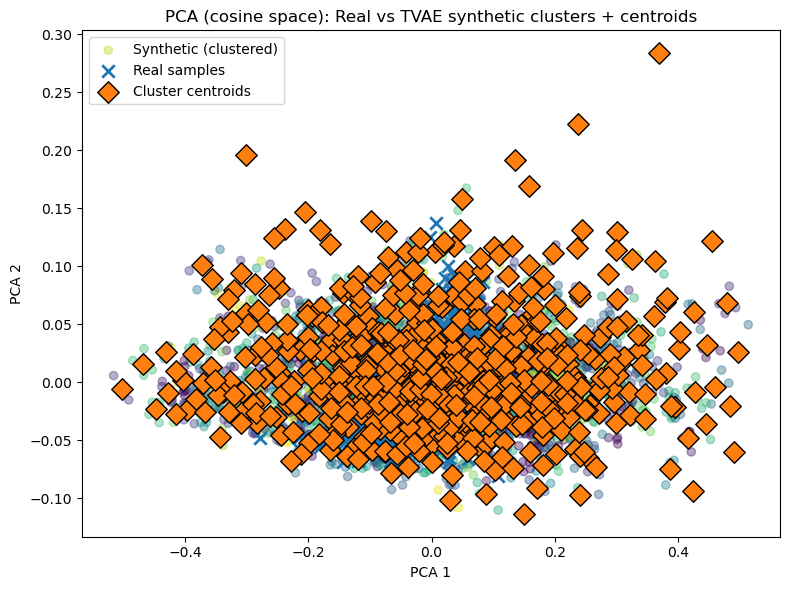

In [34]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

real_df = data

# Use all numeric features
num_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()
print(f"Using {len(num_cols)} numeric features:\n{num_cols}")

# Dict of synthetic DATAFRAMES for four models
synthetic_tables = {
    "GaussianCopula": synthetic_data_gaussian_copula,
    "CTGAN":          synthetic_data_ctgan,
    "CopulaGAN":      synthetic_data_copulagan,
    "TVAE":           synthetic_data_tvae,
}

for model_name, synth_df in synthetic_tables.items():
    print(f"\n=== PCA + clustering for {model_name} ===")

    # 1. Cluster synthetic and match to real (|S| >> |R|)
    (centroid_assignments,
     centroid_sims,
     centroids,
     cos_sim_centroids,
     synth_cluster_labels) = cluster_synthetic_and_match(
        real_df,
        synth_df,
        num_cols=num_cols,
        n_clusters=len(real_df),   # typically |R|
        random_state=42
    )

    # 2. Build matrices in cosine-normalized space
    X_real = real_df[num_cols].to_numpy(dtype=float)
    X_synth = synth_df[num_cols].to_numpy(dtype=float)

    X_real_norm = normalize_rows(X_real)
    X_synth_norm = normalize_rows(X_synth)
    centroids_norm = normalize_rows(centroids)

    n_real = X_real_norm.shape[0]
    n_synth = X_synth_norm.shape[0]
    n_centroids = centroids_norm.shape[0]

    # 3. Stack and fit PCA on unified normalized space
    X_all_norm = np.vstack([X_real_norm, X_synth_norm, centroids_norm])
    pca = PCA(n_components=2)
    X_all_2d = pca.fit_transform(X_all_norm)

    # 4. Split back into real, synthetic, and centroids
    X_real_2d = X_all_2d[:n_real]
    X_synth_2d = X_all_2d[n_real:n_real + n_synth]
    X_centroids_2d = X_all_2d[n_real + n_synth:]

    # 5. Plot
    plt.figure(figsize=(8, 6))

    # Synthetic samples (coloured by cluster label)
    plt.scatter(
        X_synth_2d[:, 0],
        X_synth_2d[:, 1],
        c=synth_cluster_labels,
        alpha=0.4,
        marker='o',
        label="Synthetic (clustered)"
    )

    # Real samples
    plt.scatter(
        X_real_2d[:, 0],
        X_real_2d[:, 1],
        marker='x',
        s=80,
        linewidths=2,
        label="Real samples"
    )

    # Cluster centroids
    plt.scatter(
        X_centroids_2d[:, 0],
        X_centroids_2d[:, 1],
        marker='D',
        s=120,
        edgecolors='black',
        label="Cluster centroids"
    )

    plt.xlabel("PCA 1")
    plt.ylabel("PCA 2")
    plt.title(f"PCA (cosine space): Real vs {model_name} synthetic clusters + centroids")
    plt.legend()
    plt.tight_layout()
    plt.show()


=== Density PCA Visualization for GaussianCopula ===


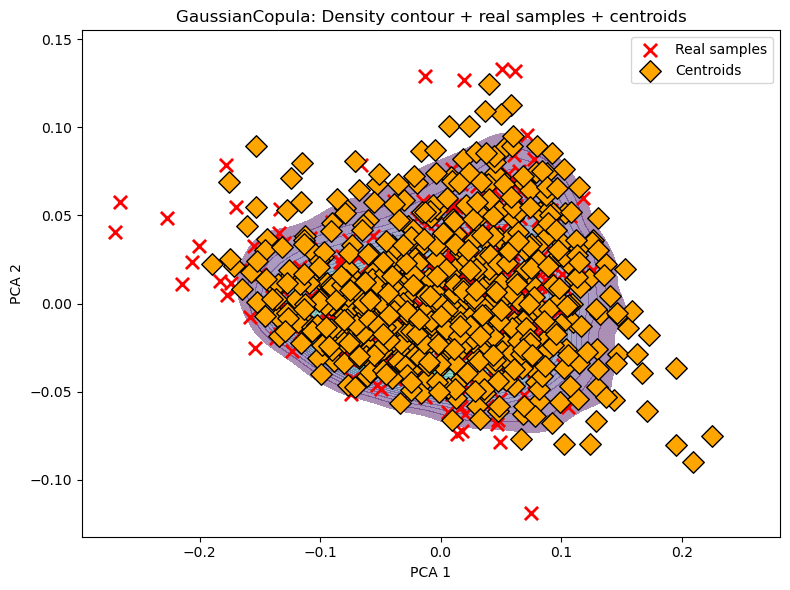


=== Density PCA Visualization for CTGAN ===


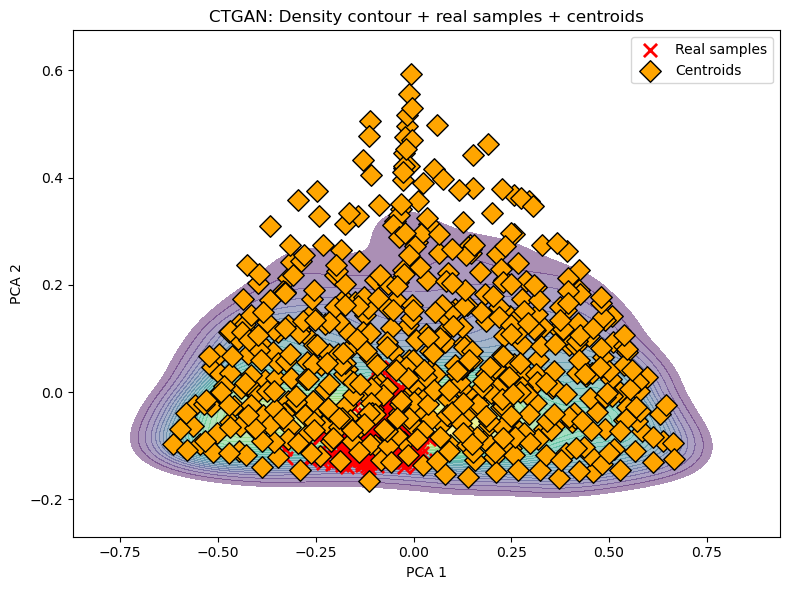


=== Density PCA Visualization for CopulaGAN ===


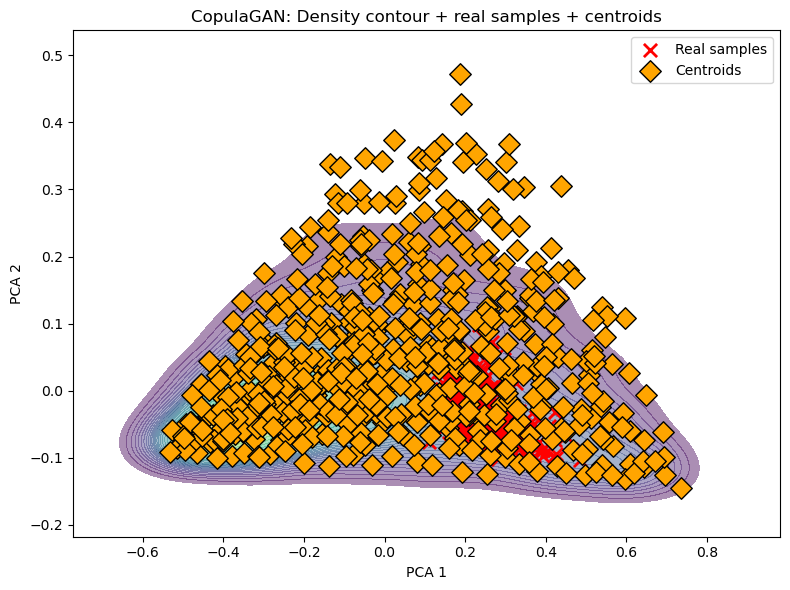


=== Density PCA Visualization for TVAE ===


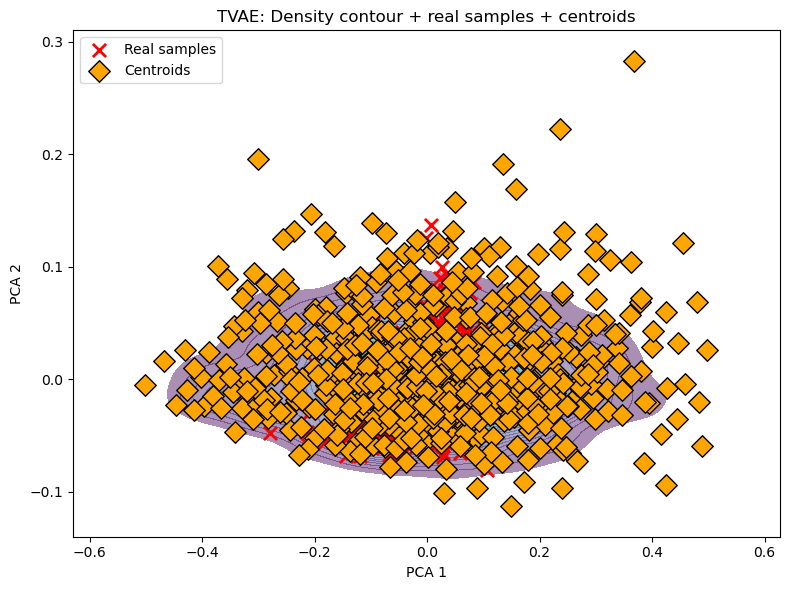

In [35]:
import seaborn as sns
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# Use all numeric features
num_cols = data.select_dtypes(include=[np.number]).columns.tolist()

synthetic_tables = {
    "GaussianCopula": synthetic_data_gaussian_copula,
    "CTGAN":          synthetic_data_ctgan,
    "CopulaGAN":      synthetic_data_copulagan,
    "TVAE":           synthetic_data_tvae,
}

for model_name, synth_df in synthetic_tables.items():
    print(f"\n=== Density PCA Visualization for {model_name} ===")

    # ------------------------------------------------------
    # 1. Cluster synthetic + match real samples
    # ------------------------------------------------------
    (centroid_assignments,
     centroid_sims,
     centroids,
     cos_sim_centroids,
     synth_cluster_labels) = cluster_synthetic_and_match(
        data,
        synth_df,
        num_cols=num_cols,
        n_clusters=len(data),
        random_state=42
    )

    # ------------------------------------------------------
    # 2. Normalize real, synthetic, and centroids (cosine)
    # ------------------------------------------------------
    X_real = data[num_cols].to_numpy(dtype=float)
    X_synth = synth_df[num_cols].to_numpy(dtype=float)

    X_real_norm = normalize_rows(X_real)
    X_synth_norm = normalize_rows(X_synth)
    centroids_norm = normalize_rows(centroids)

    n_real = X_real_norm.shape[0]
    n_synth = X_synth_norm.shape[0]
    n_centroids = centroids_norm.shape[0]

    # Stack & PCA
    X_all_norm = np.vstack([X_real_norm, X_synth_norm, centroids_norm])
    pca = PCA(n_components=2)
    X_all_2d = pca.fit_transform(X_all_norm)

    # Split back
    X_real_2d = X_all_2d[:n_real]
    X_synth_2d = X_all_2d[n_real:n_real + n_synth]
    X_centroids_2d = X_all_2d[n_real + n_synth:]

    # ------------------------------------------------------
    # 3. Density Contour Plot (Kernel Density Estimation)
    # ------------------------------------------------------
    plt.figure(figsize=(8,6))

    # Synthetic density
    sns.kdeplot(
        x=X_synth_2d[:,0],
        y=X_synth_2d[:,1],
        fill=True,
        cmap="viridis",
        alpha=0.45,
        thresh=0.05,
        levels=30
    )

    # Real samples
    plt.scatter(
        X_real_2d[:,0], X_real_2d[:,1],
        marker='x', s=90, linewidth=2, color='red',
        label="Real samples"
    )

    # Centroids
    plt.scatter(
        X_centroids_2d[:,0], X_centroids_2d[:,1],
        marker='D', s=120, edgecolors='black',
        color='orange',
        label="Centroids"
    )

    plt.title(f"{model_name}: Density contour + real samples + centroids")
    plt.xlabel("PCA 1")
    plt.ylabel("PCA 2")
    plt.legend()
    plt.tight_layout()
    plt.show()